<a href="https://colab.research.google.com/github/SanjanaNova/Quantum-Computing-/blob/main/VQE_CODING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
  import qiskit, qiskit_aer
  print("Qiskit has been imported ")
except:
  print("Installing Qiskit...")
  !pip install -U -q qiskit[visualization]
  !pip install -U -q qiskit-aer
  print("Qiskit has been installed")

Qiskit has been imported 


In [ ]:
print(qiskit.__version__)

2.3.0


# Task 1
Using Operator class from Qiskit,create Hamiltonian Z

In [ ]:
from qiskit.quantum_info import Operator

H = Operator.from_label('Z')
print(H)

Operator([[ 1.+0.j,  0.+0.j],
          [ 0.+0.j, -1.+0.j]],
         input_dims=(2,), output_dims=(2,))


# Task 2
Use SparsePauliOp class from Qiskit (which is more efficient especially when dealing with large number of qubits) to express the Hamiltonian  Z .

In [ ]:
from qiskit.quantum_info import SparsePauliOp

op = SparsePauliOp(["Z"],[1.0])
print(op)
print(op.to_matrix())
print(op.to_operator())

SparsePauliOp(['Z'],
              coeffs=[1.+0.j])
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Operator([[ 1.+0.j,  0.+0.j],
          [ 0.+0.j, -1.+0.j]],
         input_dims=(2,), output_dims=(2,))


# Task 3
Express the Hamiltonian  H=X⊗X+Y⊗Y+Z⊗Z  using SparsePauliOp and verify that it is Hermitian.

In [ ]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

op = SparsePauliOp(["XX", "YY", "ZZ"],[1.0, 1.0, 1.0])
M = op.to_matrix()
Md = np.array(M).conj().T
print(Md)
print(op)
print(op.to_matrix())

[[ 1.-0.j  0.-0.j  0.-0.j  0.-0.j]
 [ 0.-0.j -1.-0.j  2.-0.j  0.-0.j]
 [ 0.-0.j  2.-0.j -1.-0.j  0.-0.j]
 [ 0.-0.j  0.-0.j  0.-0.j  1.-0.j]]
SparsePauliOp(['XX', 'YY', 'ZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  2.+0.j  0.+0.j]
 [ 0.+0.j  2.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]]


# From IBM


In [ ]:
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp(
    [
        "IIII",
        "IIIZ",
        "IZII",
        "IIZI",
        "ZIII",
        "IZIZ",
        "IIZZ",
        "ZIIZ",
        "IZZI",
        "ZZII",
        "ZIZI",
        "YYYY",
        "XXYY",
        "YYXX",
        "XXXX",
    ],
    coeffs=[
        -0.09820182 + 0.0j,
        -0.1740751 + 0.0j,
        -0.1740751 + 0.0j,
        0.2242933 + 0.0j,
        0.2242933 + 0.0j,
        0.16891402 + 0.0j,
        0.1210099 + 0.0j,
        0.16631441 + 0.0j,
        0.16631441 + 0.0j,
        0.1210099 + 0.0j,
        0.17504456 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
    ],
)
import numpy as np

A = np.array(hamiltonian)
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("The ground state energy is ", min(eigenvalues), "hartrees")

The ground state energy is  -1.1459778447627311 hartrees


In [ ]:
# General imports
import numpy as np

# SciPy minimizer routine
from scipy.optimize import minimize

# Plotting functions
import matplotlib.pyplot as plt

In [ ]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

hamiltonian = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
)

A = np.array(hamiltonian)
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("The ground state energy is ", min(eigenvalues))

The ground state energy is  -0.702930394459531


There are many prefabricated ansatz choices in Qiskit. We will use efficient_su2.

This circuit has  4 parameters


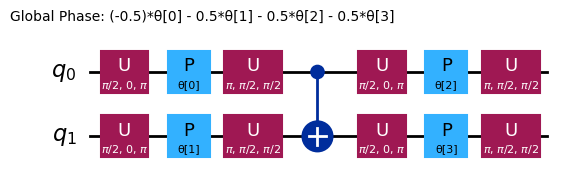

In [ ]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2

# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)

num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")

ansatz.decompose().draw("mpl", style="iqp")

#3.2 Step 2: Optimize for target hardware
The ansatz was written using familiar gates, but our circuit must be transpiled to make use of the basis gates that can be implemented on each quantum computer. We select the least busy backend.




In [ ]:
!pip install qiskit-ibm-runtime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.4/378.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.9 MB/s eta 0:00:00


In [ ]:
# runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# To run on hardware, select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)




print(backend)

AccountNotFoundError: "Unable to find account. Please make sure an account with the channel name 'ibm_quantum_platform' is saved."

In [ ]:
from qiskit_aer.primitives import Estimator as AerEstimator

estimator = AerEstimator()

print(estimator)

In [ ]:
from qiskit_aer import AerSimulator

backend = AerSimulator()


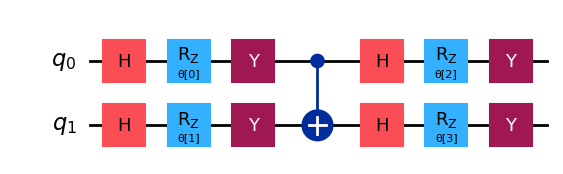

In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(
    target=target,
    optimization_level=3
)


ansatz_isa = pm.run(ansatz)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [ ]:
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

In [ ]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy


cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

In [ ]:
x0 = 2 * np.pi * np.random.random(num_params)

In [ ]:
# This required 13 min, 20 s QPU time on an Eagle processor, 28 min total time.
with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000

    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 50},
    )

Iters. done: 1 [Current cost: 0.39634244]
Iters. done: 2 [Current cost: 0.36785140000000005]
Iters. done: 3 [Current cost: 0.37231646]
Iters. done: 4 [Current cost: 0.38333596]
Iters. done: 5 [Current cost: 0.43019174000000004]
Iters. done: 6 [Current cost: 0.31862354000000004]
Iters. done: 7 [Current cost: 0.39099082]
Iters. done: 8 [Current cost: 0.29525324000000003]
Iters. done: 9 [Current cost: 0.27357856]
Iters. done: 10 [Current cost: 0.33851236]
Iters. done: 11 [Current cost: 0.31204608]
Iters. done: 12 [Current cost: 0.15086165999999998]
Iters. done: 13 [Current cost: -0.11036032000000004]
Iters. done: 14 [Current cost: -0.5281496]
Iters. done: 15 [Current cost: -0.4003281]
Iters. done: 16 [Current cost: -0.62359284]
Iters. done: 17 [Current cost: -0.36646282]
Iters. done: 18 [Current cost: -0.64474622]
Iters. done: 19 [Current cost: -0.6791796800000001]
Iters. done: 20 [Current cost: -0.66548516]
Iters. done: 21 [Current cost: -0.66740694]
Iters. done: 22 [Current cost: -0.653

In [ ]:
cost_history_dict


{'prev_vector': array([4.45951937, 0.8678184 , 3.54370113, 1.61364706]),
 'iters': 50,
 'cost_history': [np.float64(0.39634244),
  np.float64(0.36785140000000005),
  np.float64(0.37231646),
  np.float64(0.38333596),
  np.float64(0.43019174000000004),
  np.float64(0.31862354000000004),
  np.float64(0.39099082),
  np.float64(0.29525324000000003),
  np.float64(0.27357856),
  np.float64(0.33851236),
  np.float64(0.31204608),
  np.float64(0.15086165999999998),
  np.float64(-0.11036032000000004),
  np.float64(-0.5281496),
  np.float64(-0.4003281),
  np.float64(-0.62359284),
  np.float64(-0.36646282),
  np.float64(-0.64474622),
  np.float64(-0.6791796800000001),
  np.float64(-0.66548516),
  np.float64(-0.66740694),
  np.float64(-0.65371296),
  np.float64(-0.66109186),
  np.float64(-0.6862962400000001),
  np.float64(-0.6844513600000001),
  np.float64(-0.68409214),
  np.float64(-0.67772298),
  np.float64(-0.6749664),
  np.float64(-0.6834287800000001),
  np.float64(-0.6776256),
  np.float64(-0.6

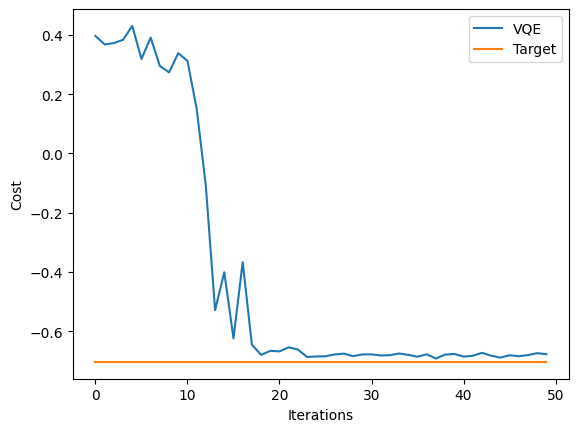

In [ ]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 50)

# Define the constant function
constant = -0.7029
y_constant = np.full_like(x, constant)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()